In [113]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


In [114]:
url = 'https://www.dropbox.com/scl/fi/rzq1fsqt7hwhmfpul1ahi/diabetes.csv?rlkey=qluuuznz7eb8fsry7j431zyx2&st=thl48em7&dl=1'
df = pd.read_csv(url)
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [115]:
#Handeling values with zero value in the dataset
col_to_fix = ['Pregnancies','Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI','DiabetesPedigreeFunction','Age']
df[col_to_fix] = df[col_to_fix].replace(0,np.nan)
df.fillna(df.median(), inplace = True)
df.head(15)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1.0,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8.0,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,4.0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
5,5.0,116.0,74.0,29.0,125.0,25.6,0.201,30,0
6,3.0,78.0,50.0,32.0,88.0,31.0,0.248,26,1
7,10.0,115.0,72.0,29.0,125.0,35.3,0.134,29,0
8,2.0,197.0,70.0,45.0,543.0,30.5,0.158,53,1
9,8.0,125.0,96.0,29.0,125.0,32.3,0.232,54,1


In [116]:
# 3. Define Features and Target
X = df.drop('Outcome', axis=1)
Y = df['Outcome']

# 4. Split and Scale
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [117]:
#Applying the Model
model = KNeighborsClassifier(n_neighbors = 8)
model.fit(X_train,Y_train)


,n_neighbors,8
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


Accuracy : 0.7207792207792207
Classification Report :               precision    recall  f1-score   support

           0       0.76      0.82      0.79        99
           1       0.62      0.55      0.58        55

    accuracy                           0.72       154
   macro avg       0.69      0.68      0.69       154
weighted avg       0.71      0.72      0.72       154



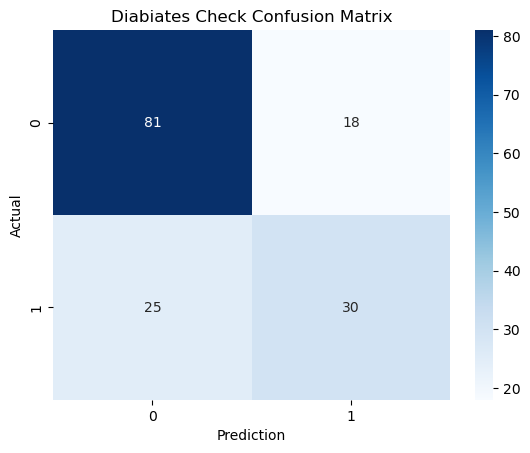


 After Reviewing the Example it has been Determined that the 

		 Patient has No Diabetes


In [118]:
#Checking the Model Accuracy
Y_pred = model.predict(X_test)
print(f"Accuracy : {accuracy_score(Y_test, Y_pred)}")
print(f"Classification Report : {classification_report(Y_test, Y_pred)}")

#Visualize Confusion Matrix
cm = confusion_matrix(Y_test,Y_pred)
sns.heatmap(cm, annot= True, fmt = 'd', cmap = 'Blues')
plt.title('Diabiates Check Confusion Matrix')
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.show()

example_predict = [[6, 168, 88, 35, 150, 36.5, 0.62, 45]]
example_predict = scaler.fit_transform(example_predict)
prediction = model.predict(example_predict)
print('\n After Reviewing the Example it has been Determined that the \n')
if prediction == 0:
    print('\t\t Patient has No Diabetes')
else:
    print('\t\t Patient has Diabetes')